# SentimentumAI — Documentación Sprint 1
**Análisis de Sentimientos de Odio en Twitter/X**

---

## Equipo de Trabajo

| Nombre | Rol | Responsabilidad |
|--------|-----|-----------------|
| Héctor Ramón Jiménez Esquivel | Product Owner | Representa la voz del cliente. Gestiona, detalla y prioriza el Product Backlog para maximizar el ROI. Define el alcance y valida incrementos en la Sprint Review. |
| Nikesha Sonalhy Mercado Escoto | Scrum Master | Líder servicial y coach. Asegura la correcta ejecución de Scrum, facilita eventos (Daily, Planning, Review, Retrospective), protege al equipo y resuelve impedimentos. |
| Carlo Eugenio Leviaguirre Chavez | Scrum Team (Dev Team) | Grupo autoorganizado. Deciden técnicamente cómo resolver el problema, ejecutan tareas, aseguran la calidad técnica y entregan un incremento utilizable por Sprint. |
| Denisse Martínez Ruíz | Scrum Team (Dev Team) | Grupo autoorganizado. Deciden técnicamente cómo resolver el problema, ejecutan tareas, aseguran la calidad técnica y entregan un incremento utilizable por Sprint. |

---

## Información del Sprint

| Campo | Valor |
|-------|-------|
| Sprint | 1 |
| Fecha de inicio | 1 de junio de 2026 |
| Fecha de cierre | 14 de junio de 2026 |
| Total Story Points | 19 |

---

## Objetivo del Sprint

> Establecer el entorno tecnológico del proyecto, importar y explorar el dataset de Twitter/X, ejecutar el pipeline completo de preprocesamiento de lenguaje natural (limpieza, normalización y vectorización TF-IDF) y obtener una matriz de texto limpia y balanceada lista para el entrenamiento de modelos clasificadores.

---

## Historias de Usuario del Sprint 1

| ID | Historia | Story Points | Prioridad | Fecha objetivo | Estado |
|----|----------|-------------|-----------|----------------|--------|
| HU-01 | Importación y exploración del dataset | 3 | Must Have | 2 jun | ✅ Completada |
| HU-02 | Limpieza y normalización de texto | 5 | Must Have | 5 jun | ⬜ Pendiente |
| HU-03 | Análisis de distribución de clases | 3 | Must Have | 3 jun | ⬜ Pendiente |
| HU-04 | Vectorización TF-IDF | 5 | Must Have | 10 jun | ⬜ Pendiente |
| HU-05 | WordClouds y análisis léxico | 3 | Should Have | 12 jun | ⬜ Pendiente |

---

## HU-01 — Importación y Exploración del Dataset

**Como** investigador social, **quiero** que el sistema importe el dataset de Twitter/X y muestre estadísticas básicas, **para** entender la estructura, volumen y calidad de los datos antes de procesarlos.

### Dataset utilizado

- **Archivo:** `twitter_train.csv`
- **Fuente:** Kaggle — Twitter Hate Speech Dataset
- **Columnas:** `id`, `label`, `tweet`
- **Total de registros:** 31,192 tweets

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

___
### Carga del Dataset

In [116]:
df_twitter = pd.read_csv("Datos/twitter_train.csv")

___
### Exploración básica

In [117]:
display(df_twitter.head(3))

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty


In [118]:
print(df_twitter.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31962 entries, 0 to 31961
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      31962 non-null  int64 
 1   label   31962 non-null  int64 
 2   tweet   31962 non-null  object
dtypes: int64(2), object(1)
memory usage: 749.2+ KB
None


In [119]:
print(df_twitter.describe().T)

         count          mean          std  min      25%      50%       75%  \
id     31962.0  15981.500000  9226.778988  1.0  7991.25  15981.5  23971.75   
label  31962.0      0.070146     0.255397  0.0     0.00      0.0      0.00   

           max  
id     31962.0  
label      1.0  


In [120]:
print(f"Columnas totales del dataset: {df_twitter.shape[0]}")
print(f"Filas totales del dataset: {df_twitter.shape[1]}")

Columnas totales del dataset: 31962
Filas totales del dataset: 3


In [121]:
print("=== TIPOS DE DATOS ===")
print(df_twitter.dtypes)

=== TIPOS DE DATOS ===
id        int64
label     int64
tweet    object
dtype: object


In [122]:
print("=== ANÁLISIS DE NULOS Y DUPLICADOS ===")
print(F"Total de nulos: \n{df_twitter.isnull().sum()}")
print(f"Total de duplicados: {df_twitter.duplicated().sum()}")

=== ANÁLISIS DE NULOS Y DUPLICADOS ===
Total de nulos: 
id       0
label    0
tweet    0
dtype: int64
Total de duplicados: 0


In [123]:
print("=== ANÁLISIS DE DISTRIBUCIÓN DE CLASES ===")
print("Distribución por conteo")
print(df_twitter["label"].value_counts())
print("Distribución por porcentaje")
print(df_twitter["label"].value_counts(normalize=True)*100)

=== ANÁLISIS DE DISTRIBUCIÓN DE CLASES ===
Distribución por conteo
label
0    29720
1     2242
Name: count, dtype: int64
Distribución por porcentaje
label
0    92.98542
1     7.01458
Name: proportion, dtype: float64


Se observa un desbalance importante, con un total del **93% no odio vs un 7% odio**. Esto es relevante ya qye los modelos tienden a ignorar la clase minoritaria. 

Se deberá considerar una estratégia de balanceo en futuros pasos.

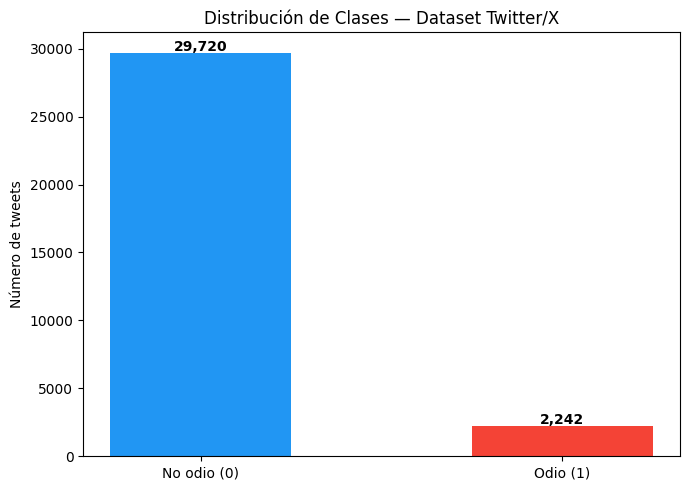

In [124]:
fig, ax = plt.subplots(figsize=(7, 5))

conteo = df_twitter["label"].value_counts()
colores = ['#2196F3', '#F44336']
etiquetas = ['No odio (0)', 'Odio (1)']
barras = ax.bar(etiquetas, conteo.values, color= colores, width= 0.5)

for barra, valor in zip(barras, conteo.values):
    ax.text(barra.get_x() + barra.get_width()/2,
            barra.get_height() + 100,
            f'{valor:,}', ha='center', fontweight='bold')

ax.set_title('Distribución de Clases — Dataset Twitter/X')
ax.set_ylabel('Número de tweets')
plt.tight_layout()
plt.savefig('distribucion_clases.png', dpi=150)
plt.show()


### Resultados Obtenidos

| Métrica | Valor |
|---------|-------|
| Total de tweets | 31,962 |
| Columnas | 3 (`id`, `label`, `tweet`) |
| Valores nulos | 0 |
| Tweets duplicados | 0 |
| Tweets sin odio (label=0) | 29,720 (92.99%) |
| Tweets de odio (label=1) | 2,242 (7.01%) |

### Criterios de Aceptación

- [x] El dataset se carga correctamente desde archivo CSV
- [x] Se visualizan las primeras filas, tipos de datos y dimensiones del DataFrame
- [x] Se reporta el número total de tweets y la distribución inicial de etiquetas
- [x] Se identifican valores nulos o duplicados

### Hallazgos Clave

> **Desbalance de clases:** El dataset presenta un desbalance significativo con una proporción de 13:1 entre tweets sin odio y tweets de odio (92.99% vs 7.01%), superando el umbral crítico de 3:1. Se requerirá una estrategia de balanceo antes del entrenamiento (oversampling, undersampling o ajuste de `class_weight`). Esto se aborda en HU-03.

---

## HU-02 — Limpieza y Normalización de Texto

**Como** desarrollador del equipo, **quiero** aplicar un pipeline de limpieza al campo `tweet`, **para** eliminar ruido textual y mejorar la calidad de los datos de entrada al modelo.

In [135]:
# ============================================================
# SentimentumAI — HU-02: Limpieza y normalización de texto
# Equipo: Carlo Leviaguirre, Denisse Martínez
# Sprint 1 | Semana 1
# ============================================================
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [126]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    #Normalizamos el texto a minúsculas
    text = text.lower()
    #A través de funciones regex eliminamos URLS
    text = re.sub(r'http\S+|www\S+', '', text)
    #A través de funciones regex eliminamos mencinoes
    text = re.sub(r'@\w+','', text)
    #A través de funciones regex eliminamos hashtags 
    text = re.su
### Decisiones Técnicas

> **Lematización sobre Stemming:** Se eligió `WordNetLemmatizer` en lugar de `PorterStemmer` porque la lematización devuelve la forma correcta del diccionario, preservando el significado de palabras clave relacionadas con discurso de odio. El stemming puede distorsionar palabras críticas para el análisis (ej. "hate" → "hat").

> **Pipeline clásico sobre Transformers:** Se evaluó el uso de Hugging Face Transformers para mejor comprensión de contexto y sarcasmo. Se descartó para Sprint 1 por ser inconsistente con el roadmap definido (Bloque B: TF-IDF). Los transformers se integrarán en Sprint 2 como mejora comparativa sobre el baseline.
b(r'#\w+', '', text)
    #Conservamos únicamnetes letras y espacios
    text = re.sub(r'[^a-z\s]', '', text) 
    #Dividimos el texto por palabras
    tokens = text.split()
    #Para cada palabra que no forma parte del stopword aplicamos stem y guaradmos en tokens
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)
                 

In [127]:
df_twitter['clean_tweet'] = df_twitter['tweet'].apply(clean_text)
display(df_twitter[['tweet', 'clean_tweet']].head(10))

,tweet,clean_tweet
0,@user when a father is dysfunctional and is s...,father dysfunctional selfish drag kid dysfunction
1,@user @user thanks for #lyft credit i can't us...,thanks credit cant use cause dont offer wheelc...
2,bihday your majesty,bihday majesty
3,#model i love u take with u all the time in ...,love u take u time ur
4,factsguide: society now #motivation,factsguide society
5,[2/2] huge fan fare and big talking before the...,huge fan fare big talking leave chaos pay disp...
6,@user camping tomorrow @user @user @user @use...,camping tomorrow danny
7,the next school year is the year for exams.ð...,next school year year exam cant think
8,we won!!! love the land!!! #allin #cavs #champ...,love land
9,@user @user welcome here ! i'm it's so #gr...,welcome im


In [128]:
print(clean_text("we won!!! love the land!!!"))

love land


In [129]:
text = "we won!!! love the land!!!"
text = text.lower()
print("1. lower:", text)
text = re.sub('http\S+|www\S+', '', text)
print("2. sin URLs:", text)
text = re.sub('@\w+', '', text)
print("3. sin menciones:", text)
text = re.sub('#\w+', '', text)
print("4. sin hashtags:", text)
text = re.sub('[^a-z ]', '', text)
print("5. sin especiales:", text)
tokens = text.split()
print("6. tokens:", tokens)
tokens = [stemmer.stem(w) for w in tokens if w not in stop_words]
print("7. sin stopwords:", tokens)

1. lower: we won!!! love the land!!!
2. sin URLs: we won!!! love the land!!!
3. sin menciones: we won!!! love the land!!!
4. sin hashtags: we won!!! love the land!!!
5. sin especiales: we won love the land
6. tokens: ['we', 'won', 'love', 'the', 'land']
7. sin stopwords: ['love', 'land']


In [130]:
#Verificación de nulos o blancos 

In [133]:
tweets_vacios = df_twitter[(df_twitter['clean_tweet'].str.strip() == '') | (df_twitter['clean_tweet'].isna())].shape[0]
print(f"El total de tweets vacios después de la limpieza: {tweets_vacios}")
print(f"El porcentaje es: {tweets_vacios/len(df_twitter)*100:.2f}%")

El total de tweets vacios después de la limpieza: 452
El porcentaje es: 1.41%


In [134]:
df_twitter = df_twitter[(df_twitter['clean_tweet'].str.strip() != '') & (df_twitter['clean_tweet'].notna())]
print(f"Total de tweets después de limpieza: {df_twitter.shape[0]}")

Total de tweets después de limpieza: 31510


### Decisiones Técnicas

> **Lematización sobre Stemming:** Se eligió `WordNetLemmatizer` en lugar de `PorterStemmer` porque la lematización devuelve la forma correcta del diccionario, preservando el significado de palabras clave relacionadas con discurso de odio. El stemming puede distorsionar palabras críticas para el análisis (ej. "hate" → "hat").

> **Pipeline clásico sobre Transformers:** Se evaluó el uso de Hugging Face Transformers para mejor comprensión de contexto y sarcasmo. Se descartó para Sprint 1 por ser inconsistente con el roadmap definido (Bloque B: TF-IDF). Los transformers se integrarán en Sprint 2 como mejora comparativa sobre el baseline.


## Resultados Obtenidos

| Métrica | Valor |
|---------|-------|
| Total original | 31,962 tweets |
| Tweets vacíos post-limpieza | 452 (1.41%) |
| Tweets con texto válido | 31,510 (98.59%) |
| Criterio mínimo requerido | 95% |

### Criterios de Aceptación

- [x] Se eliminan URLs, menciones, hashtags, caracteres especiales y números
- [x] Se convierte el texto a minúsculas
- [x] Se aplica tokenización y eliminación de stopwords en inglés
- [x] Se aplica lematización con `WordNetLemmatizer`
- [x] Se crea la columna `clean_tweet` con el texto procesado
- [x] Al menos el 95% de los tweets tienen texto limpio no vacío (resultado: 98.59%)

---

## Resultados Obtenidos

| Métrica | Valor |
|---------|-------|
| Total original | 31,962 tweets |
| Tweets vacíos post-limpieza | 452 (1.41%) |
| Tweets con texto válido | 31,510 (98.59%) |
| Criterio mínimo requerido | 95% |

### Criterios de Aceptación

- [x] Se eliminan URLs, menciones, hashtags, caracteres especiales y números
- [x] Se convierte el texto a minúsculas
- [x] Se aplica tokenización y eliminación de stopwords en inglés
- [x] Se aplica lematización con `WordNetLemmatizer`
- [x] Se crea la columna `clean_tweet` con el texto procesado
- [x] Al menos el 95% de los tweets tienen texto limpio no vacío (resultado: 98.59%)

---